# 3C — Train CNN on CSD PDFs with automatic labels (label-scheme comparison)

This notebook is a comparison run against `3C-train-model-CSD.ipynb`
(the published `csd_no_attention` model).

- **Same data**: the 645 calculated PDFs in `csd_structures/calculated_pdfs/`
  (r = 2–12 Å slice, identical reading code).
- **Different labels**: instead of the manual nuclearity prefix in the
  filename, labels come from the automatic `prepare_cifs.py` classification
  rules (Ln–O/N/F/Cl single-atom-bridge entity graph, bond tol 0.4 Å),
  precomputed by `/workspace/home/pdf-nn-data/csd2023/relabel_csd_structures.py`
  into `labels/csd_labels_auto_manifest.csv` (all 700 CIFs) and
  `labels/csd_labels_auto.txt` (one label per .dat, glob order; finite
  nuclearity >= 10 folded into class 10 = polymer).
- **Models** are saved under `models/csd_auto_labels/` — nothing from
  `models/csd_no_attention/` is touched.

Everything else (hyperband tuning, 5-fold stratified CV with 200 epochs,
best-fold selection, saliency maps) is identical to the original notebook,
so val_accuracy differences are attributable to the label scheme alone.


In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import math

# Python 3.7 compatibility for keras_tuner (uses math.prod)
if not hasattr(math, "prod"):
    def _prod(values):
        result = 1
        for value in values:
            result *= int(value)
        return result

    math.prod = _prod

2026-09-11 08:44:42.709366: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-11 08:44:42.995686: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 08:44:43.002964: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /workspace/home/.local/opt/tmux/usr

In [2]:
# Import path configuration
import sys
import importlib
sys.path.insert(0, '..')  # Add parent directory to path

# Force reload to pick up any config changes
import config
from config import setup_workdir, get_path
# Set working directory to CSD calculated PDFs
setup_workdir('csd_calculated_pdfs')

Working directory: /workspace/home/pdf-nn-data/csd_structures/calculated_pdfs


In [3]:
# Get calculated PDFs — recalculated set (dedup + PDFCalculator, 2026-09-09)
# calculated_pdfs_dedup/ holds the corrected PDFs; the original calculated_pdfs/
# (published Debye-convention baseline) stays untouched.
csd_pdfs_dir = get_path('csd_structures') / 'calculated_pdfs_dedup'
# sorted() is CRITICAL: on this NFS filesystem glob returns arbitrary order,
# while the labels file is written in sorted order (2026-09-11: unsorted glob
# misaligned labels with PDFs -> 0.33 accuracy; sorted -> proper training).
files_calc = sorted(glob.glob(str(csd_pdfs_dir / '*.dat')))
print(f'Using recalculated PDFs: {csd_pdfs_dir} ({len(files_calc)} files)')


Using recalculated PDFs: /workspace/home/pdf-nn-data/csd_structures/calculated_pdfs_dedup (700 files)


Counts of CSD structures by their nuclearity: {'1': 74, '2': 170, '3': 6, '4': 107, '5': 7, '6': 32, '7': 20, '8': 17, '9': 30, 'polymer': 237}
Total number of structures: 700


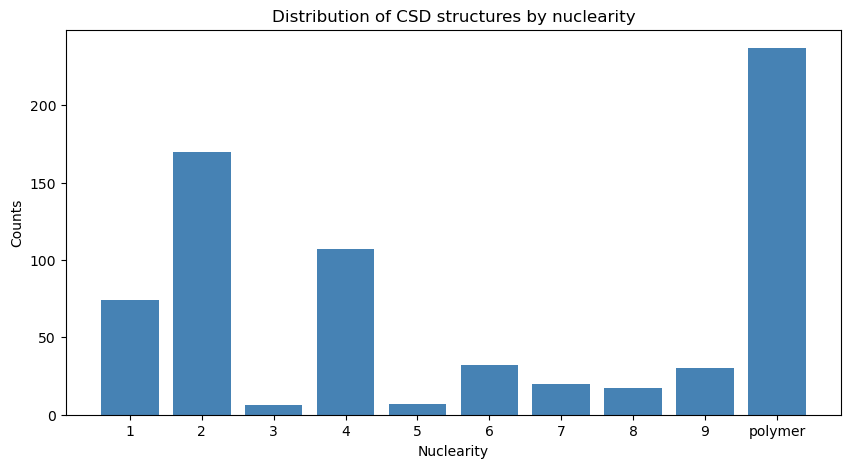

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9, plus 'p' for 10
    counts = defaultdict(int)
    for filepath in filenames:
        filename = os.path.basename(filepath)
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
        elif filename[0] == 'p':
            counts['10'] += 1
            
    return counts

counts = analyze_filenames(files_calc)
# Include nuclearity 10 for CSD structures (coordination polymers)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
sorted_counts['polymer'] = counts.get('10', 0)

print("Counts of CSD structures by their nuclearity:", sorted_counts)
print(f"Total number of structures: {len(files_calc)}")

digits = list(sorted_counts.keys())
values = list(sorted_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(digits, values, color='steelblue')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.title('Distribution of CSD structures by nuclearity')
plt.show()

In [5]:
# Setup output directories — automatic-labels comparison run
labels_dir = get_path('labels')
models_dir = get_path('csd_auto_labels_models')
labels_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Labels were precomputed by relabel_csd_structures.py using the automatic
# prepare_cifs.py classification rules (one line per .dat file, glob order;
# finite nuclearity >= 10 folded into class '10'). Regenerated 2026-09-09 for
# the full 700-file recalculated set.
labels_file = labels_dir / 'csd_labels_auto.txt'
print(f'Reading labels from: {labels_file}')

raw_data_points = []

for f in files_calc:
    df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')
    raw_data_points.append(df.values.ravel())

raw_data_points = np.array(raw_data_points)

# Load the labels (order matches files_calc = sorted glob)
labels = pd.read_csv(labels_file, header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

print(f'Loaded {len(labels)} labels for {len(files_calc)} PDFs')
print(f'Label distribution: {pd.Series(labels).value_counts().sort_index().to_dict()}')
print(f'Models will be saved to: {models_dir}')


Reading labels from: /workspace/home/pdf-nn-data/labels/csd_labels_auto.txt
Loaded 700 labels for 700 PDFs
Label distribution: {1: 162, 2: 113, 3: 6, 4: 111, 5: 7, 6: 33, 7: 20, 8: 17, 9: 28, 10: 203}
Models will be saved to: /workspace/home/pdf-nn-data/models/csd_auto_labels


1


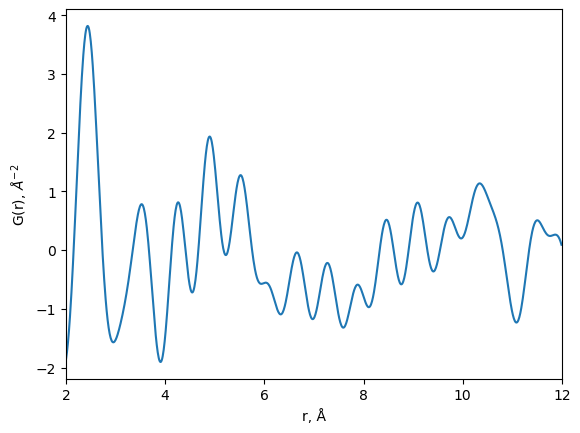

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
# Per-sample z-scoring (2026-09-10): mean 0 / std 1 per PDF. The previous
# per-sample L2 Normalizer left small-amplitude PDFs at a feature scale where
# hyperband's early stopping favored degenerate over-regularized configs.
data_points = (raw_data_points - raw_data_points.mean(axis=1, keepdims=True)) / raw_data_points.std(axis=1, keepdims=True)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[77,:]))/100+2, data_points[77,:])
plt.xlabel('r, Å')
plt.ylabel('G(r), $Å^{-2}$')
print(labels[77])

In [7]:
# Hyperparameter tuning

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [8]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42, stratify=labels)

In [9]:

# Setup hyperband directory within models folder
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=200,
    factor=3,
    directory=str(models_dir),
    project_name='hyperband_csd_auto_labels',
    overwrite = True
)

tuner.search(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=10)])
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hyperparameters.values)

# Extract best hyperparameters for retraining
best_filters1 = best_hyperparameters.get('filters1')
best_kernel_size1 = best_hyperparameters.get('kernel_size1')
best_filters2 = best_hyperparameters.get('filters2')
best_kernel_size2 = best_hyperparameters.get('kernel_size2')
best_dropout = best_hyperparameters.get('dropout')
best_dense_units = best_hyperparameters.get('dense_units')
best_learning_rate = best_hyperparameters.get('learning_rate')

print(f"\nExtracted hyperparameters for retraining:")
print(f"  filters1: {best_filters1}, kernel_size1: {best_kernel_size1}")
print(f"  filters2: {best_filters2}, kernel_size2: {best_kernel_size2}")
print(f"  dropout: {best_dropout}, dense_units: {best_dense_units}")
print(f"  learning_rate: {best_learning_rate}")

best_model = tuner.get_best_models(num_models=1)[0]

# Save best model to models directory
best_model_path = models_dir / 'tuned_csd_auto_labels.h5'
best_model.save(best_model_path)
print(f"\nBest model saved to: {best_model_path}")

Trial 254 Complete [00h 00m 36s]
val_accuracy: 0.7928571701049805

Best val_accuracy So Far: 0.8642857074737549
Total elapsed time: 00h 55m 23s
Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
Best hyperparameters:
{'filters1': 16, 'kernel_size1': 128, 'dropout': 0.

In [10]:
def create_model():
    # Create model using best hyperparameters from tuning
    model = Sequential()
    # Add the convolutional layers
    model.add(Conv1D(filters=best_filters1, kernel_size=best_kernel_size1, activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(best_dropout))
    model.add(Conv1D(filters=best_filters2, kernel_size=best_kernel_size2, activation='relu'))
    model.add(Dropout(best_dropout))

    # Flatten the output of the convolutional layers
    model.add(Flatten())

    # Add the fully connected layers
    model.add(Dense(units=best_dense_units, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(best_dropout))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))

    # Compile the model with the best learning rate
    optimizer = Adam(learning_rate=best_learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [11]:
num_folds = 5
num_epochs = 200
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1 
all_fold_results = []
histories = []

In [12]:
# Setup directory for fold models
folds_dir = models_dir / 'cv_folds'
folds_dir.mkdir(parents=True, exist_ok=True)
histories_json = models_dir / 'cv_histories.json'

# Node-death resilience: after every fold, append its history to
# cv_histories.json; at fold start, skip training if both the fold's .h5 and
# its entry in cv_histories.json already exist.
import json
cv_histories = json.loads(histories_json.read_text()) if histories_json.exists() else {}

for train_index, val_index in kf.split(data_points, labels):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]

    checkpoint_path = folds_dir / f"csd_fold_{fold_num}_model.h5"
    fold_key = str(fold_num)

    if checkpoint_path.exists() and fold_key in cv_histories:
        print(f'Fold {fold_num}: checkpoint + history found, skipping training.')
        history = type('H', (), {'history': cv_histories[fold_key]})()
        histories.append(history)
        load_model = keras.models.load_model(str(checkpoint_path))
        val_loss, val_acc = load_model.evaluate(X_val, y_val, verbose=0)
        print(f'Fold {fold_num} accuracy (loaded):', val_acc)
        all_fold_results.append(val_acc)
        fold_num += 1
        continue

    model = create_model()

    checkpoint = ModelCheckpoint(str(checkpoint_path), monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

    print(f'Training fold {fold_num}...')
    history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    histories.append(history)

    # Persist history so this fold can be skipped on a restart
    cv_histories[fold_key] = history.history
    histories_json.write_text(json.dumps(cv_histories))

    # Load the best model saved by the checkpoint and evaluate
    load_model = keras.models.load_model(str(checkpoint_path))

    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)

    all_fold_results.append(val_acc)

    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))
print(f"\nFold models saved to: {folds_dir}")

Training fold 1...
Epoch 1/200
17/18 [===========================>..] - ETA: 0s - loss: 4.6565 - accuracy: 0.3860
Epoch 1: val_accuracy improved from -inf to 0.55714, saving model to /workspace/home/pdf-nn-data/models/csd_auto_labels/cv_folds/csd_fold_1_model.h5
18/18 [==============================] - 2s 56ms/step - loss: 4.6394 - accuracy: 0.3893 - val_loss: 4.6552 - val_accuracy: 0.5571
Epoch 2/200
17/18 [===========================>..] - ETA: 0s - loss: 3.9248 - accuracy: 0.5735
Epoch 2: val_accuracy improved from 0.55714 to 0.65714, saving model to /workspace/home/pdf-nn-data/models/csd_auto_labels/cv_folds/csd_fold_1_model.h5
18/18 [==============================] - 1s 45ms/step - loss: 3.9129 - accuracy: 0.5750 - val_loss: 4.4730 - val_accuracy: 0.6571
Epoch 3/200
17/18 [===========================>..] - ETA: 0s - loss: 3.6315 - accuracy: 0.6875
Epoch 3: val_accuracy improved from 0.65714 to 0.72857, saving model to /workspace/home/pdf-nn-data/models/csd_auto_labels/cv_folds/csd

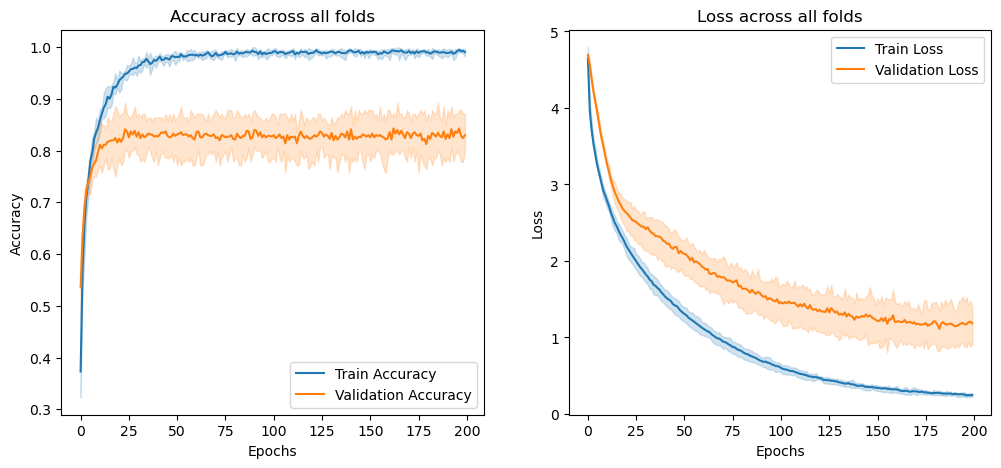

In [13]:
# Identifying the best fold (assuming higher validation accuracy is better)
best_fold_index = np.argmax([np.max(hist.history['val_accuracy']) for hist in histories])

# Collect metrics across all folds (truncate to shortest fold length)
min_epochs = min(len(h.history['accuracy']) for h in histories)
all_train_acc = np.array([h.history['accuracy'][:min_epochs] for h in histories])
all_val_acc = np.array([h.history['val_accuracy'][:min_epochs] for h in histories])
all_train_loss = np.array([h.history['loss'][:min_epochs] for h in histories])
all_val_loss = np.array([h.history['val_loss'][:min_epochs] for h in histories])

epochs = np.arange(min_epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.fill_between(epochs, all_train_acc.min(axis=0), all_train_acc.max(axis=0), alpha=0.2, color='tab:blue')
plt.plot(epochs, all_train_acc.mean(axis=0), color='tab:blue', linewidth=1.5, label='Train Accuracy')
plt.fill_between(epochs, all_val_acc.min(axis=0), all_val_acc.max(axis=0), alpha=0.2, color='tab:orange')
plt.plot(epochs, all_val_acc.mean(axis=0), color='tab:orange', linewidth=1.5, label='Validation Accuracy')
plt.title('Accuracy across all folds')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.fill_between(epochs, all_train_loss.min(axis=0), all_train_loss.max(axis=0), alpha=0.2, color='tab:blue')
plt.plot(epochs, all_train_loss.mean(axis=0), color='tab:blue', linewidth=1.5, label='Train Loss')
plt.fill_between(epochs, all_val_loss.min(axis=0), all_val_loss.max(axis=0), alpha=0.2, color='tab:orange')
plt.plot(epochs, all_val_loss.mean(axis=0), color='tab:orange', linewidth=1.5, label='Validation Loss')
plt.title('Loss across all folds')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Loading best model from fold 4: /workspace/home/pdf-nn-data/models/csd_auto_labels/cv_folds/csd_fold_4_model.h5
5/5 [==============================] - 0s 12ms/step
Recall score: [0.97297297 0.95454545 0.66666667 0.95652174 1.         1.
 0.66666667 1.         1.         0.97674419]
F1 score: [0.96       0.93333333 0.8        0.97777778 1.         1.
 0.8        0.85714286 0.66666667 0.98823529]
Precision score: [0.94736842 0.91304348 1.         1.         1.         1.
 1.         0.75       0.5        1.        ]
Confusion matrix, without normalization
[[36  1  0  0  0  0  0  0  0  0]
 [ 1 21  0  0  0  0  0  0  0  0]
 [ 0  1  2  0  0  0  0  0  0  0]
 [ 1  0  0 22  0  0  0  0  0  0]
 [ 0  0  0  0  2  0  0  0  0  0]
 [ 0  0  0  0  0  3  0  0  0  0]
 [ 0  0  0  0  0  0  2  0  1  0]
 [ 0  0  0  0  0  0  0  3  0  0]
 [ 0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  1  0 42]]


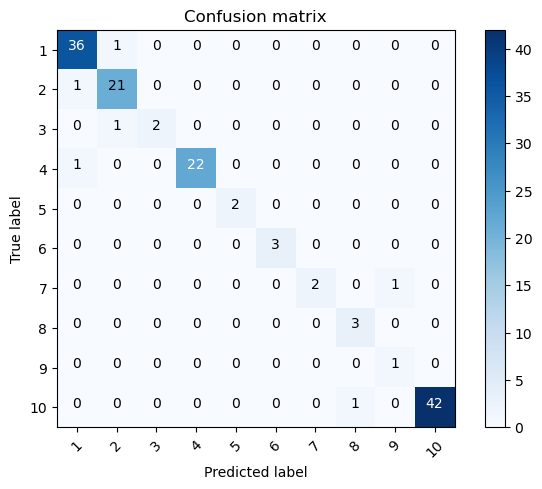

In [14]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)

# Load the best model from cross-validation (best fold determined from training)
best_fold = np.argmax(all_fold_results) + 1  # +1 because fold_num starts at 1
best_model_path = models_dir / 'cv_folds' / f'csd_fold_{best_fold}_model.h5'
print(f"Loading best model from fold {best_fold}: {best_model_path}")

load_model = keras.models.load_model(best_model_path)

load_model.evaluate(X_val, y_val)
y_pred_prob = load_model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_val, y_pred)
recall = recall_score(y_val, y_pred, average=None)
f1 = f1_score(y_val, y_pred, average=None)
precision = precision_score(y_val, y_pred, average=None)
#print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_val), title='Confusion matrix', normalize=False)
plt.show()

In [15]:
# Attention layer extraction skipped - no attention mechanism in this model version

In [16]:
# Skipping attention weights plot - no attention mechanism in this model version
print("Note: This model does not include an attention mechanism, so attention weight visualization is not applicable.")

Note: This model does not include an attention mechanism, so attention weight visualization is not applicable.


Sample label: 10


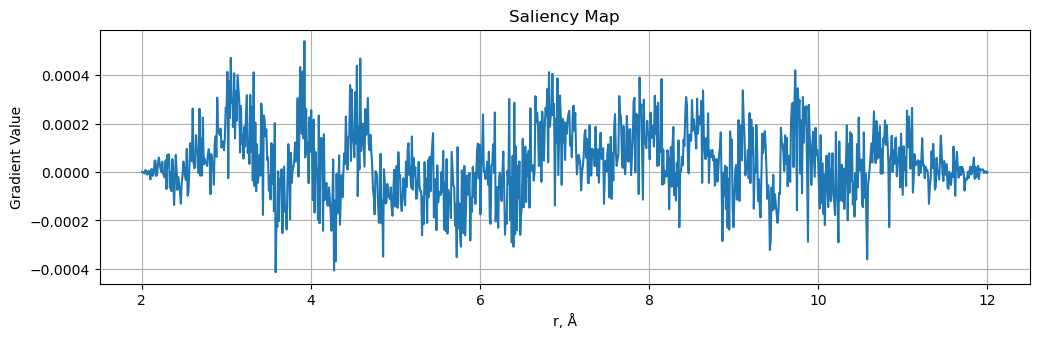

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Use the loaded model from cross-validation
model = load_model

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 6  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 1000, 1), dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(1000)
print(f"Sample label: {y_train[sample_index]}")
angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100

# Plot
plt.figure(figsize=(12, 3.3))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

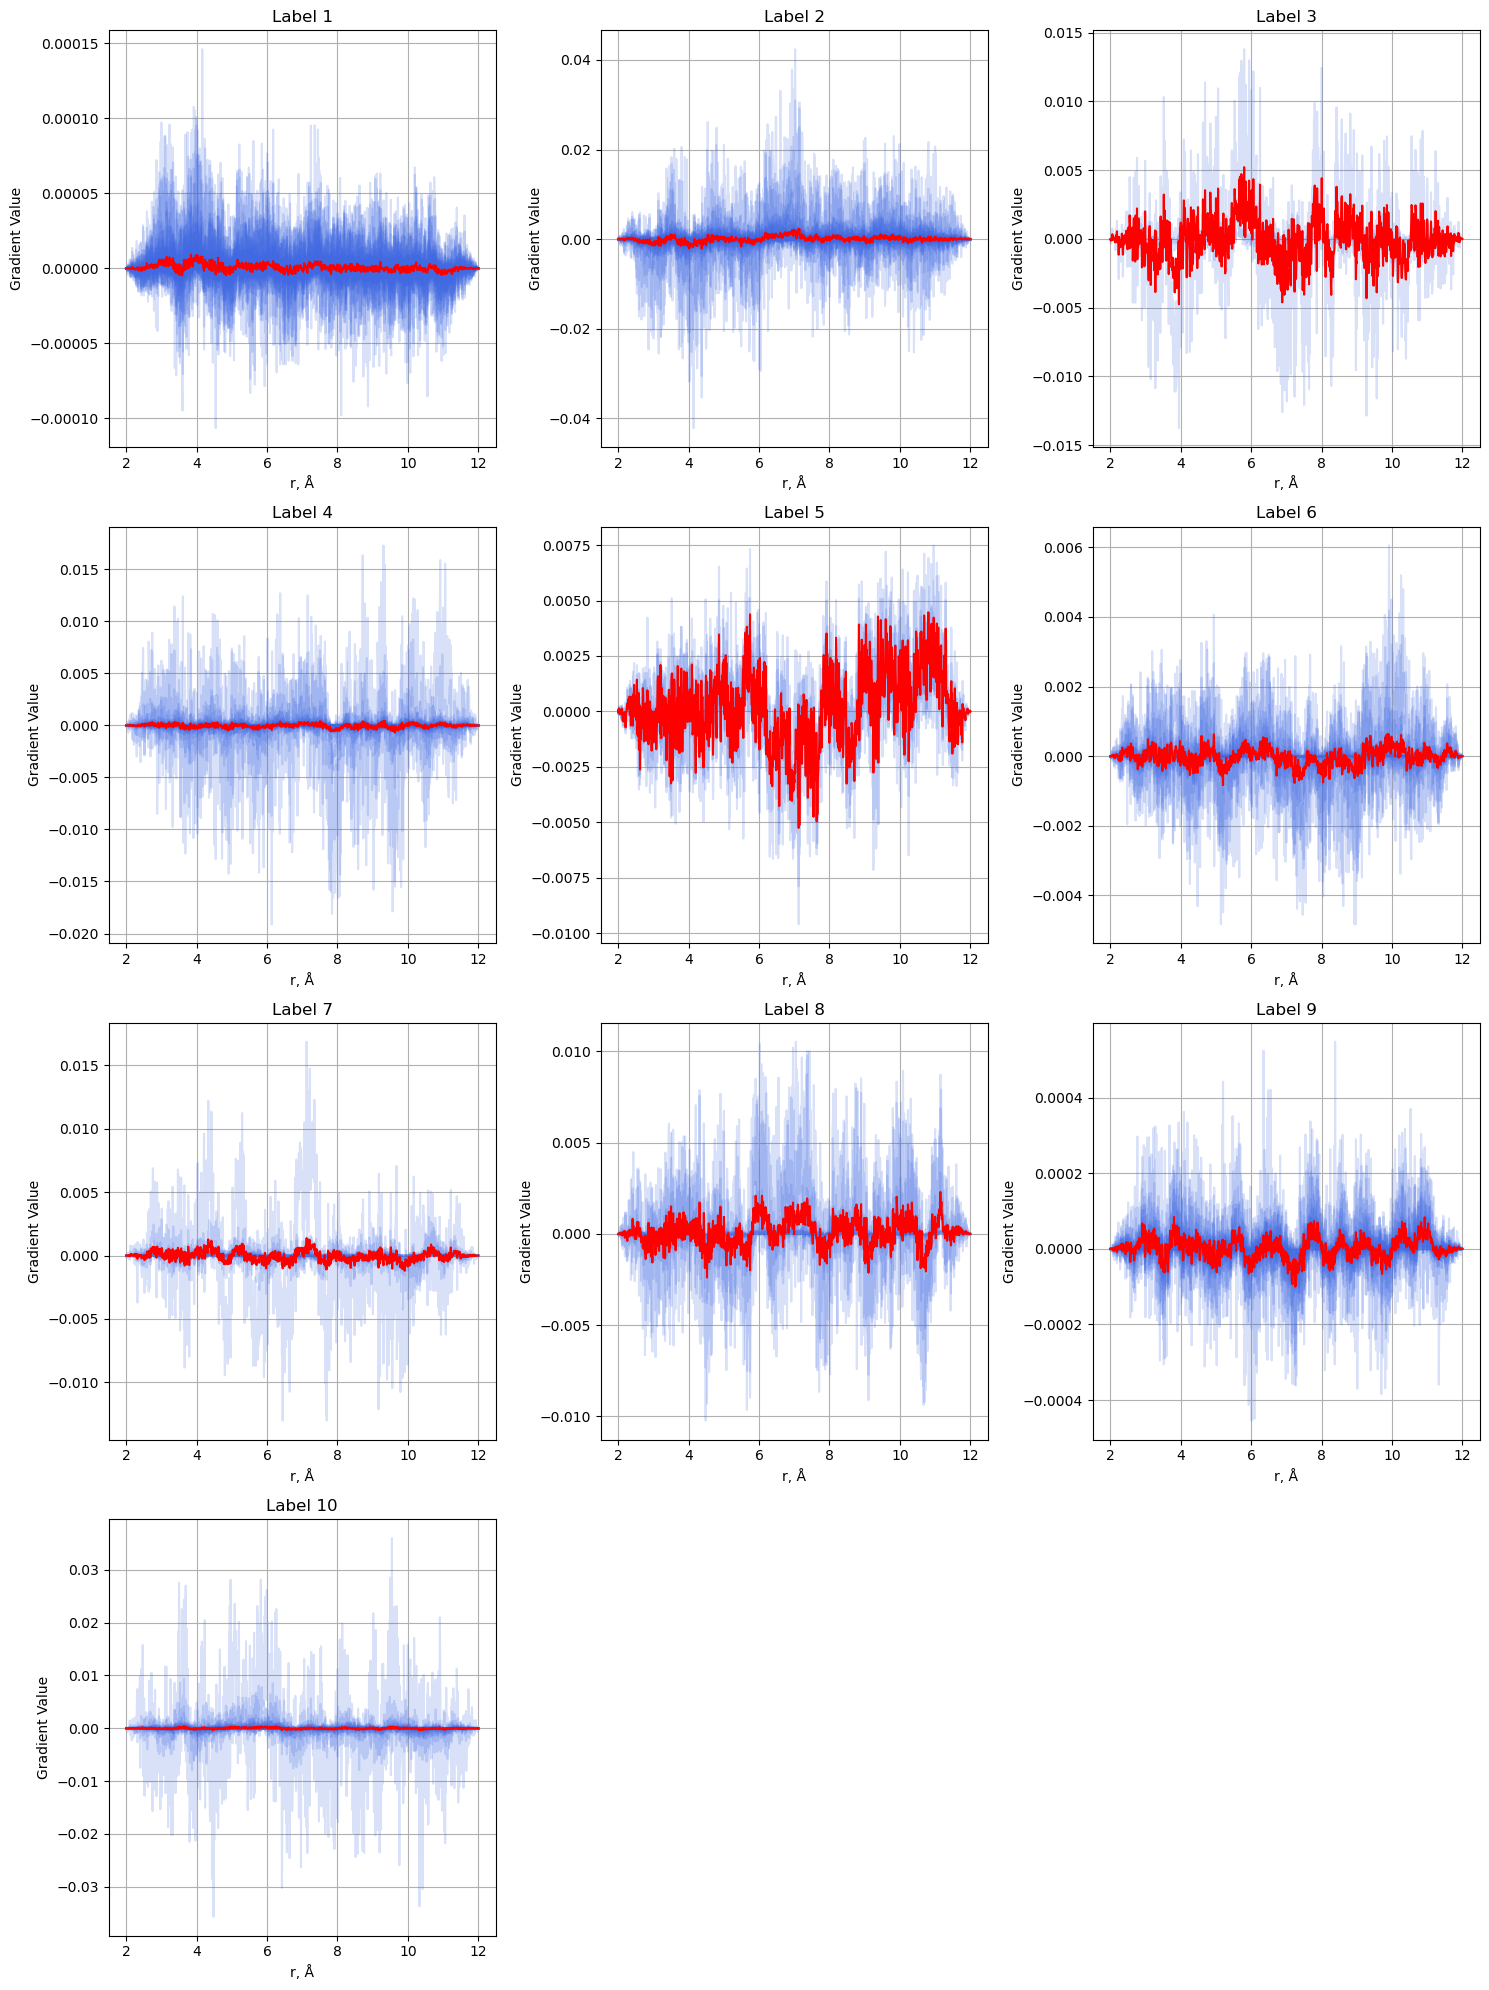

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 400
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# Loop through the unique labels (from 1 to 10)
for label in range(1, 11):
    ax = axes[(label - 1) // 3, (label - 1) % 3]
    gradients = []
    
    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 1000, 1), dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label - 1]  # Adjust for 0-based index
            
            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(1000)
            gradients.append(grad_numpy)
            
            angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='royalblue')
    
    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red')
    
    ax.set_title(f'Label {label}')
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

fig.delaxes(axes[3,1])
fig.delaxes(axes[3,2])

plt.tight_layout()

# Save to figures directory
figures_dir = get_path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'csd_saliency_maps_auto_labels.png', dpi=400)
plt.show()

## Status

Long-running headless run (hyperband + 5-fold CV, ~3–5 h on CPU). Check progress with:

```bash
ls /workspace/home/pdf-nn-data/models/csd_auto_labels/
tail logs/3C_auto-labels.log
```

- `cv_folds/csd_fold_N_model.h5` appear one per completed fold; `cv_histories.json`
  accumulates one entry per fold (the notebook skips re-training a fold whose
  .h5 + history entry already exist, so it can be re-launched after a node death).
- Executed output lands in `complete workflow/3C-train-model-CSD-auto-labels-executed.ipynb`.
- After training, run `complete workflow/3C-compare-label-schemes.ipynb` for the
  old-vs-auto label comparison and experimental .gr predictions.
